### House Price Prediction - Comprehensive EDA & Hypothesis Testing


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import os
VIS_DIR = "visualizations"
os.makedirs(VIS_DIR, exist_ok=True)

In [2]:
#Load Dataset
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (1460, 81)
Test shape:  (1459, 80)


In [3]:
train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
#Split columns by type
numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train.select_dtypes(include=['object', 'string']).columns.tolist()

numerical_cols.remove('Id')
numerical_cols.remove('SalePrice')

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 36
Categorical features: 43


In [7]:
#Missing values
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_df)

              missing_count  missing_pct
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
MasVnrType              872        59.73
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageType               81         5.55
GarageYrBlt              81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
GarageCond               81         5.55
BsmtExposure             38         2.60
BsmtFinType2             38         2.60
BsmtQual                 37         2.53
BsmtCond                 37         2.53
BsmtFinType1             37         2.53
MasVnrArea                8         0.55
Electrical                1         0.07


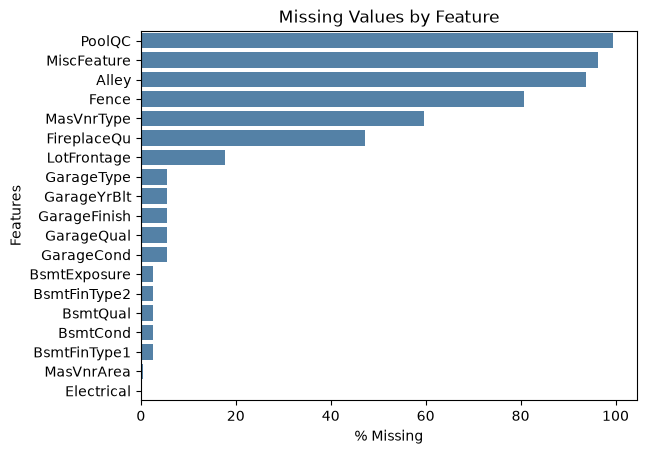

In [8]:
sns.barplot(x=missing_df['missing_pct'], y=missing_df.index, color='steelblue')
plt.xlabel('% Missing')
plt.ylabel("Features")
plt.title('Missing Values by Feature')
plt.savefig('visualizations/missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

## Target Variable Analysis (SalePrice)

In [9]:
train['SalePrice'].describe()


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

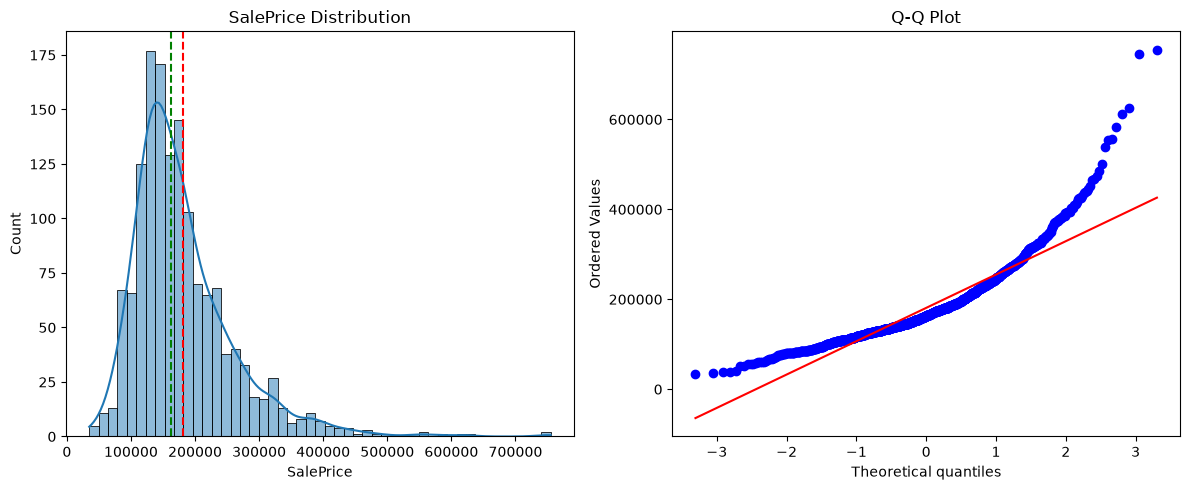

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("SalePrice Distribution")
axes[0].axvline(train['SalePrice'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(train['SalePrice'].median(), color='green', linestyle='--', label='Median')

stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig('visualizations/saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Skewness:", train['SalePrice'].skew())
print("Kurtosis:", train['SalePrice'].kurt())


### Interpretation

The distribution of SalePrice is right-skewed, meaning that most houses are sold at lower to moderate prices, while a smaller number of houses have very high prices. Because of this skewness, a log transformation was applied to make the target variable closer to a normal distribution. This is useful for regression models because many models perform better when the target variable is less skewed.

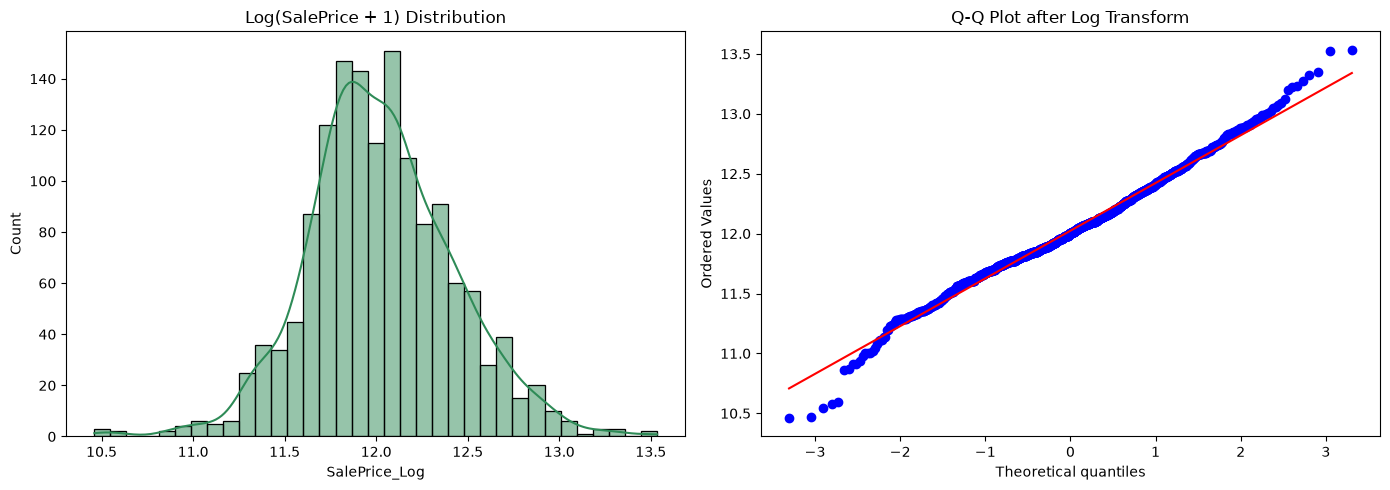

Skewness after log transform: 0.1213


In [11]:
# Log-transform to correct skew
train['SalePrice_Log'] = np.log1p(train['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['SalePrice_Log'], kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Log(SalePrice + 1) Distribution')

stats.probplot(train['SalePrice_Log'], plot=axes[1])
axes[1].set_title('Q-Q Plot after Log Transform')

plt.tight_layout()
plt.savefig('visualizations/saleprice_log_transform.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Skewness after log transform: {train['SalePrice_Log'].skew():.4f}")

### 3. Feature Analysis - Numerical Features

In [12]:
# Descriptive statistics for numerical features
train[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [13]:
# Correlation of numerical features with SalePrice
correlations = (
    train[numerical_cols + ['SalePrice']]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)
print("Top 10 positively correlated features with SalePrice:")
print(correlations.head(10))
print("\nTop 5 negatively correlated features with SalePrice:")
print(correlations.tail(5))

Top 10 positively correlated features with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

Top 5 negatively correlated features with SalePrice:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


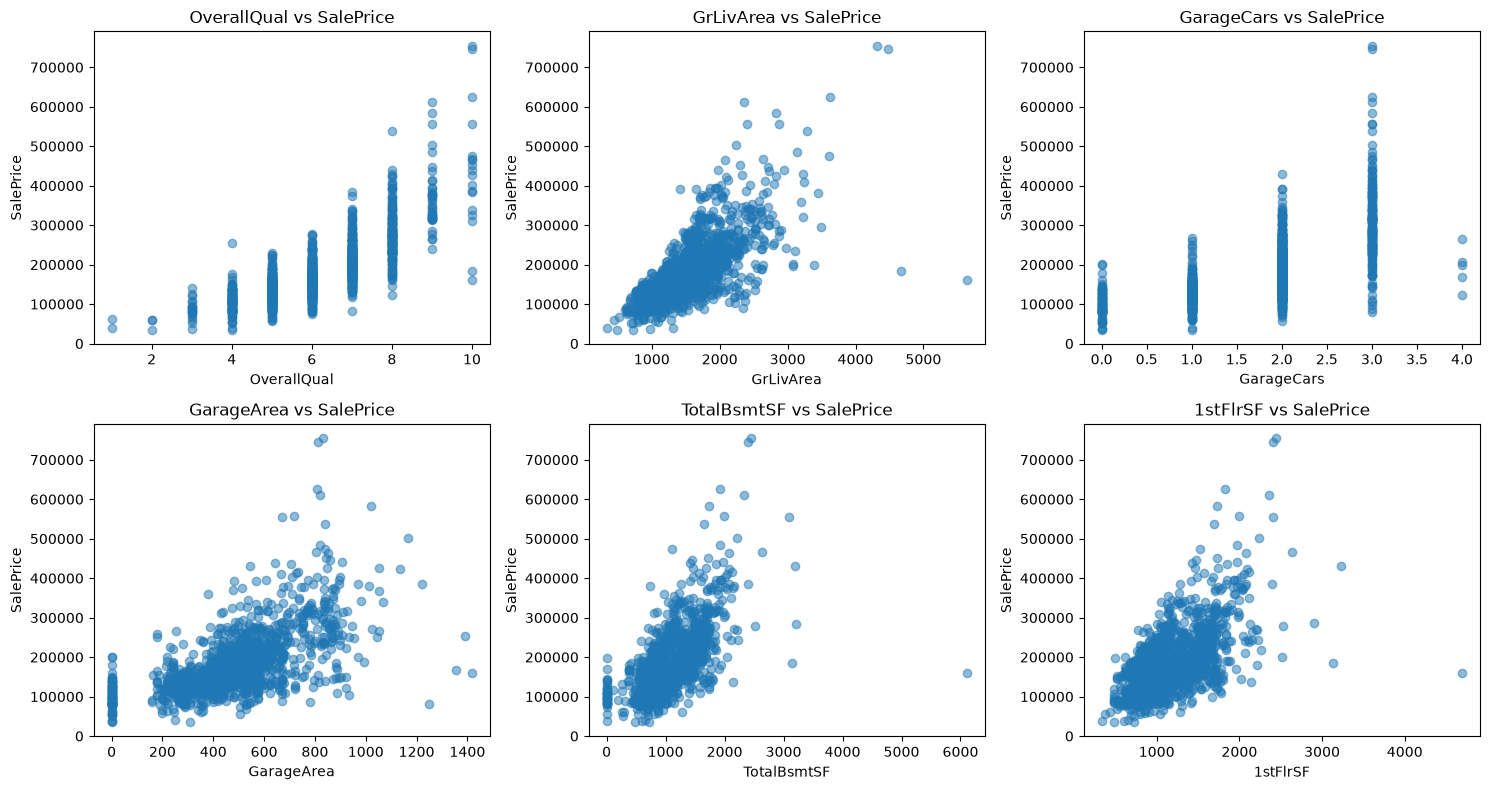

In [14]:
# Scatter plots: top correlated numerical features vs SalePrice
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(train[feature], train['SalePrice'], alpha=0.5)
    axes[i].set_title(f"{feature} vs SalePrice")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SalePrice")

plt.tight_layout()
plt.savefig('visualizations/top_features_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

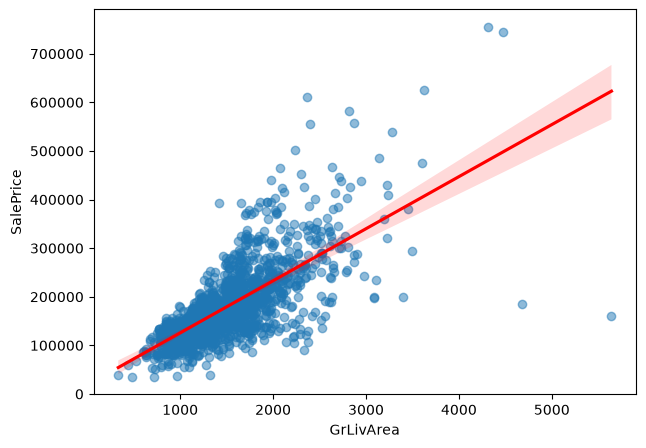

In [15]:
plt.figure(figsize=(7,5))
sns.regplot(
    x='GrLivArea',
    y='SalePrice',
    data=train,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.savefig('visualizations/grliv_area_regression.png', dpi=300, bbox_inches='tight')
plt.show()

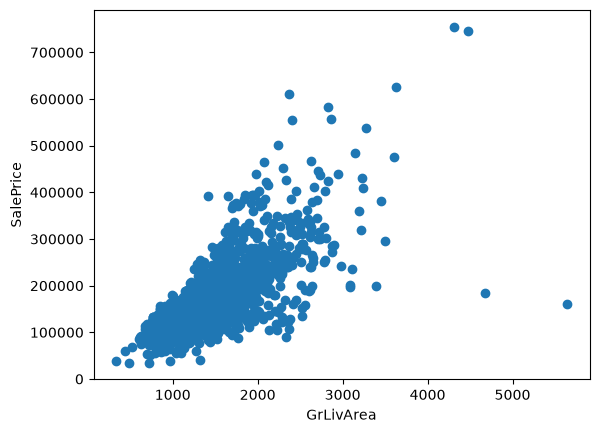

,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [16]:
# Check for obvious outliers in GrLivArea
plt.scatter(train['GrLivArea'], train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]

outliers[['Id', 'GrLivArea', 'SalePrice']]

### 4. Feature Analysis - Categorical Features

In [17]:
# How many categories does each categorical feature have?
for col in categorical_cols:
    print(f"{col}: {train[col].nunique()} categories")

MSZoning: 5 categories
Street: 2 categories
Alley: 2 categories
LotShape: 4 categories
LandContour: 4 categories
Utilities: 2 categories
LotConfig: 5 categories
LandSlope: 3 categories
Neighborhood: 25 categories
Condition1: 9 categories
Condition2: 8 categories
BldgType: 5 categories
HouseStyle: 8 categories
RoofStyle: 6 categories
RoofMatl: 8 categories
Exterior1st: 15 categories
Exterior2nd: 16 categories
MasVnrType: 3 categories
ExterQual: 4 categories
ExterCond: 5 categories
Foundation: 6 categories
BsmtQual: 4 categories
BsmtCond: 4 categories
BsmtExposure: 4 categories
BsmtFinType1: 6 categories
BsmtFinType2: 6 categories
Heating: 6 categories
HeatingQC: 5 categories
CentralAir: 2 categories
Electrical: 5 categories
KitchenQual: 4 categories
Functional: 7 categories
FireplaceQu: 5 categories
GarageType: 6 categories
GarageFinish: 3 categories
GarageQual: 5 categories
GarageCond: 5 categories
PavedDrive: 3 categories
PoolQC: 3 categories
Fence: 4 categories
MiscFeature: 4 categor

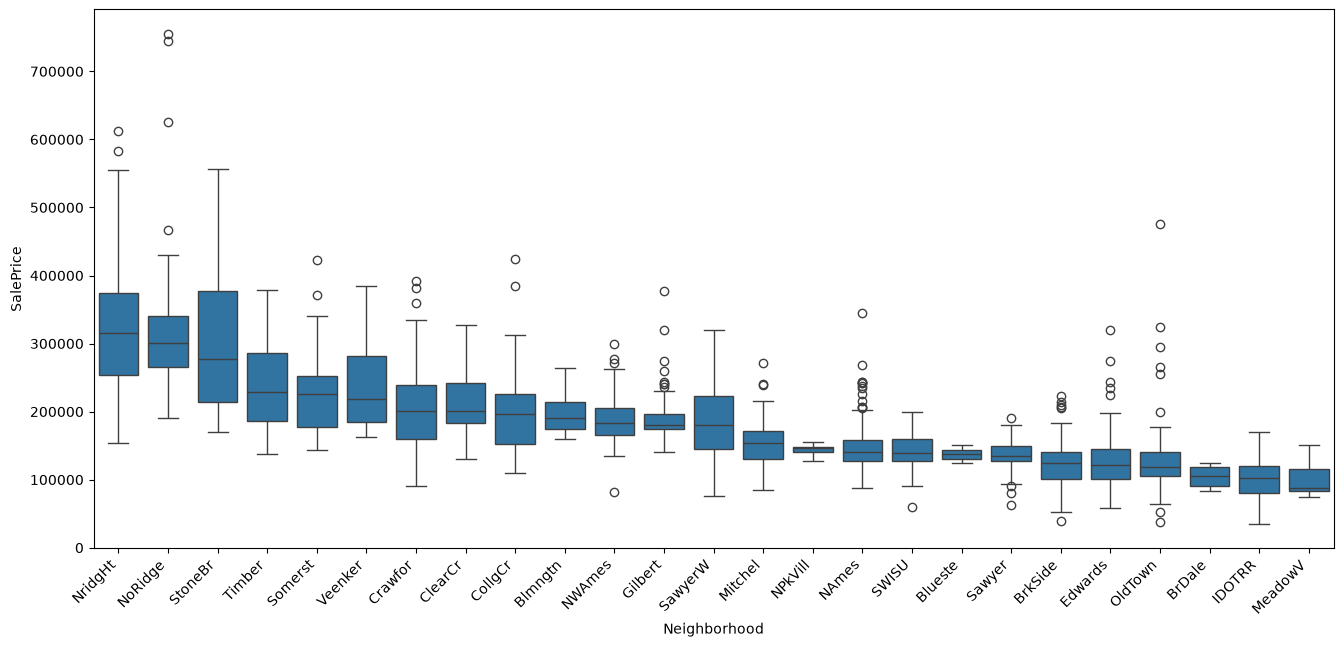

In [18]:
plt.figure(figsize=(16, 7))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=order)
plt.xticks(rotation=45, ha='right')
plt.savefig("visualizations/neighborhood_boxplot.png",dpi=300,bbox_inches="tight")
plt.show()

### Neighborhood Insight

The boxplot shows that SalePrice varies substantially across neighborhoods. Some neighborhoods such as NoRidge, NridgHt, and StoneBr tend to have higher median prices, while neighborhoods such as MeadowV, IDOTRR, and BrDale tend to have lower median prices. This suggests that location is an important factor in house price prediction.

In [19]:
# Average SalePrice by neighborhood
nbhd_avg = train.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
print("Top 5 highest-priced neighborhoods:")
print(nbhd_avg.head(5))
print("\nBottom 5 lowest-priced neighborhoods:")
print(nbhd_avg.tail(5))

Top 5 highest-priced neighborhoods:
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64

Bottom 5 lowest-priced neighborhoods:
Neighborhood
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


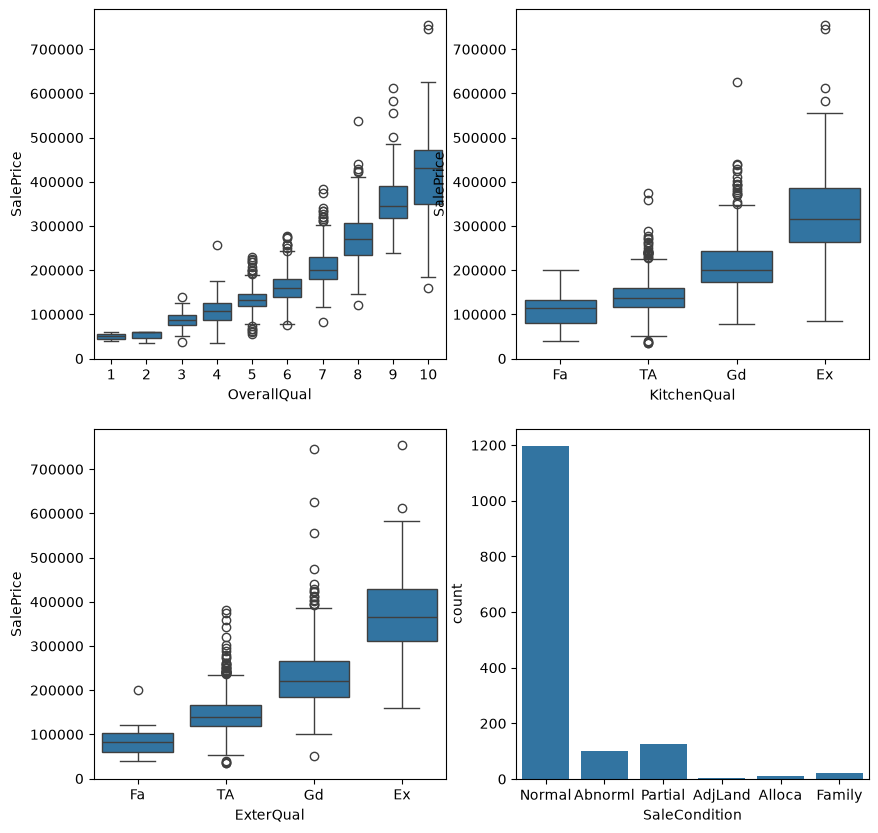

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=axes[0, 0])

sns.boxplot(data=train, x='KitchenQual', y='SalePrice',
            order=['Fa', 'TA', 'Gd', 'Ex'], ax=axes[0, 1])

sns.boxplot(data=train, x='ExterQual', y='SalePrice',
            order=['Fa', 'TA', 'Gd', 'Ex'], ax=axes[1, 0])

sns.countplot(data=train, x='SaleCondition', ax=axes[1, 1])
plt.savefig('visualizations/categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

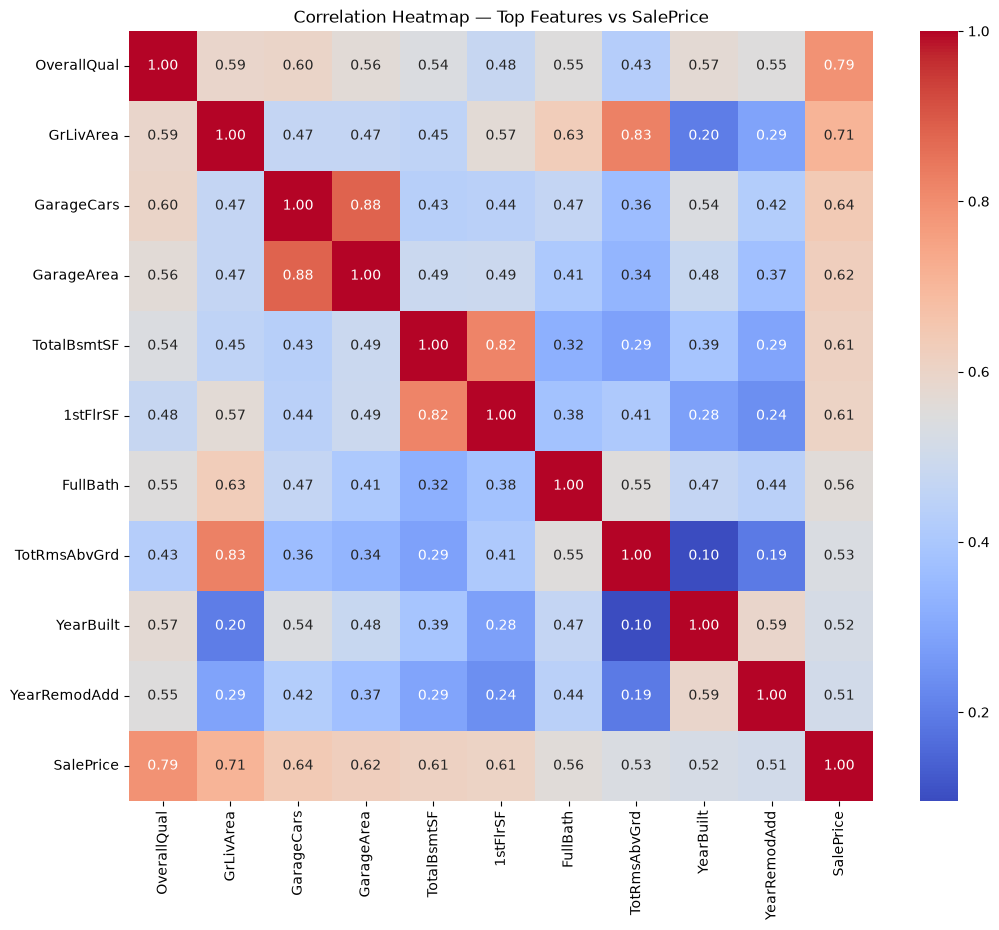

In [21]:
# Full correlation matrix among top numerical features + target
top_corr_features = correlations.head(10).index.tolist() + ['SalePrice']
corr_matrix = train[top_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — Top Features vs SalePrice')
plt.savefig('visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Insights

The strongest positive correlations with SalePrice are usually features such as OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF. This indicates that house quality, above-ground living area, garage capacity, and basement size are important factors influencing house prices.

### 6. Hypothesis Testing

In [22]:
# Hyopthesis 1 - Pearson coefficient test
# H0 : There is no linear correlation between GrLivArea and SalePrice
# H1 : There is a significant positive correlation between GrLivArea and SalePrice
r1, p1 = stats.pearsonr(train['GrLivArea'], train['SalePrice'])
print(f"Pearson r = {r1:.4f}")
print(f"p-value   = {p1:.2e}")

if p1 < 0.05:
    print("\nResult: Reject H0 -> statistically significant positive correlation.")
else:
    print("\nResult: Fail to reject H0.")

Pearson r = 0.7086
p-value   = 4.52e-223

Result: Reject H0 -> statistically significant positive correlation.


Since the p-value is less than 0.05 and the Pearson correlation coefficient is positive, we reject the null hypothesis. This means there is a statistically significant positive relationship between above-ground living area and house price.

In [25]:
### Hypothesis 2 - One-way ANOVA
# H0: Average `SalePrice` does not differ significantly across neighborhoods.
# H1: Houses in certain neighborhoods have significantly different average prices than others.

neighborhood_groups = [group['SalePrice'].values for name, group in train.groupby('Neighborhood')]

f_stat, p2 = stats.f_oneway(*neighborhood_groups)
print(f"Number of neighborhoods: {train['Neighborhood'].nunique()}")
print(f"F-statistic = {f_stat:.2f}")
print(f"p-value     = {p2:.2e}")

if p2 < 0.05:
    print("\nResult: Reject H0 -> at least one neighborhood has a significantly different mean price.")
else:
    print("\nResult: Fail to reject H0.")


Number of neighborhoods: 25
F-statistic = 71.78
p-value     = 1.56e-225

Result: Reject H0 -> at least one neighborhood has a significantly different mean price.


In [24]:
### Hypothesis 3 - Pearson correlation coefficient 
# H0: There is no linear correlation between house age and `SalePrice`.
# H1: The age of the house has a significant negative correlation with `SalePrice`.

train['HouseAge'] = train['YrSold'] - train['YearBuilt']

r3, p3 = stats.pearsonr(train['HouseAge'], train['SalePrice'])
print(f"Pearson r = {r3:.4f}")
print(f"p-value   = {p3:.2e}")

if p3 < 0.05 and r3 < 0:
    print("\nResult: Reject H0 -> statistically significant negative correlation.")
else:
    print("\nResult: Fail to reject H0 or correlation not in expected direction.")

Pearson r = -0.5234
p-value   = 1.86e-103

Result: Reject H0 -> statistically significant negative correlation.


## Summary of Key EDA Insights

1. The target variable, SalePrice, is right-skewed. A log transformation reduces skewness and makes the distribution closer to normal.
2. OverallQual has one of the strongest positive relationships with SalePrice, indicating that overall material and finish quality strongly influence house prices.
3. GrLivArea is strongly positively correlated with SalePrice, meaning larger houses generally sell for higher prices.
4. GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF also show positive relationships with SalePrice.
5. Neighborhood has a clear effect on house prices. Some neighborhoods have much higher median and average prices than others.
6. Older houses tend to have lower prices, shown by the negative correlation between HouseAge and SalePrice.
7. Some outliers exist, especially houses with very large living areas but relatively low sale prices. These should be reviewed before model training.
8. Several features contain missing values. Some missing values represent the absence of a feature, such as no pool, no garage, no basement, or no alley access.